# Dell Kit Date Prediction - Case Study
**Goal:** predict `kit_end` for respective order in `inference.parquet`.

## 1. Problem formulation
- **Target:** kit duration in days = `kit_end - kit_start`. Predicted `kit_end = kit_start + predicted duration`.
- **Why duration, not the date:** the date is not stationary. Duration is, and it lets us reuse the calendar and factory context.
- **Regression or classification?** Duration is a small integer (about 47% are 1 day, 15-20% are 0, long tail to 76). I frame it as multiclass classification (0,1,...,6, 7+) and predict the **median of the predicted distribution**. That minimises absolute error in days, which is what a planner feels.
- **Validation:** time-based. Inference is a *future* period (Feb-Mar 2026), so I trained on orders starting before 2025-12-15 and validate on 2025-12-15 to 2026-01-31. No random splits.
- **Metrics:** MAE in days, exact-date hit rate, and within +/-1 day rate. Compared to simple baselines, as seen fit.

## Assumptions
See the docstring in the next cell. Key ones: A2 (drop 734 bad-target rows from training), A3 (dedupe capacity), A5 (workload features use the known batch of orders by start date, never kit_end).
 ##
The records cover one site (KHO), and this analysis does not show that performance transfers to other sites. More than one-fifth of inference rows lack expected kit minutes. The median-based model has limited differentiation and cannot account for changing congestion or staffing from the supplied data. The exact-day hit rate is below 50%; the typical absolute error is one day. Classification results depend on arbitrary duration buckets and must not be interpreted as SLA performance.

In [ ]:
import numpy as np, pandas as pd, lightgbm as lgb, matplotlib.pyplot as plt, warnings, json
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize':(8,4),'axes.grid':True,'grid.alpha':.3})
OUT='/mnt/user-data/outputs/'

## 2. Pipeline Code (load, clean, features)
Each function is documented.

In [ ]:
import numpy as np
import pandas as pd

DATA = "/mnt/user-data/uploads/"  # <- change to your data folder

### 1. LOAD

In [ ]:
def load():
    tr = pd.read_parquet(DATA + "train.parquet")
    inf = pd.read_parquet(DATA + "inference.parquet")
    cal = pd.read_parquet(DATA + "calendar.parquet")
    cap = pd.read_parquet(DATA + "capacity.parquet")
    em = pd.read_parquet(DATA + "expected_minutes.parquet")
    return tr, inf, cal, cap, em

### 2. CLEAN

In [ ]:
def clean(tr, inf, cal, cap, em):
    # Decimal-typed columns -> numeric
    for d in (tr, inf):
        for c in ["buid", "tie_num", "quantity_produced", "line_qty"]:
            d[c] = pd.to_numeric(d[c].astype(str), errors="coerce")
    # A3: capacity one row per date
    cap = cap.dropna(subset=["date"]).drop_duplicates("date")
    # expected minutes: numeric, drop null family, one row per family
    em = em.dropna(subset=["family_desc"]).copy()
    for c in ["expected_build_minutes", "expected_burn_minutes", "expected_kit_minutes"]:
        em[c] = pd.to_numeric(em[c].astype(str), errors="coerce")
    em = em.drop_duplicates("family_desc")
    # target
    tr["dur"] = (tr.kit_end - tr.kit_start).dt.days
    return tr, inf, cal, cap, em

### 3. FEATURES

In [ ]:
def build_features(tr, inf, cal, cap, em):
    tr = tr.copy(); inf = inf.copy()
    tr["is_train"] = 1; inf["is_train"] = 0
    df = pd.concat([tr, inf], ignore_index=True)

    # --- order-level
    df["log_amt"] = np.log1p(df.order_amt)
    df["amt_per_unit"] = df.order_amt / df.quantity_produced.replace(0, np.nan)
    df["dl_lag"] = (df.kit_start - df.download_date).dt.days          # download -> kit start wait
    df["ship_gap"] = (df.est_ship_date - df.kit_start).dt.days        # promised slack
    df["mcid_is_site"] = (df.mcid == df.site).astype(int)
    df["n_ties_in_order"] = df.groupby("sales_order_id").tie_num.transform("nunique")
    df["n_rows_in_order"] = df.groupby("sales_order_id").sales_order_id.transform("size")
    df["qty_share"] = df.quantity_produced / df.line_qty.replace(0, np.nan)

    # --- product minutes (24.5% of train rows have no family match -> NaN, LightGBM handles it)
    df = df.merge(em, on="family_desc", how="left")
    df["kit_min_total"] = df.expected_kit_minutes * df.quantity_produced
    df["burn_min_total"] = df.expected_burn_minutes * df.quantity_produced

    # --- calendar at kit_start
    cal = cal.drop_duplicates("date").rename(columns={"date": "kit_start"})
    keep = ["kit_start", "fiscal_qtr", "fiscal_month", "fiscal_qtr_weeknum", "day_of_week",
            "is_weekend", "is_holiday", "is_idc", "is_eoq"]
    df = df.merge(cal[keep], on="kit_start", how="left")
    df["dow"] = df.kit_start.dt.dayofweek
    df["dom"] = df.kit_start.dt.day
    df["month"] = df.kit_start.dt.month

    # --- capacity at kit_start
    cap = cap.rename(columns={"date": "kit_start", "ot_flag": "cap_ot_flag",
                              "ot_hours": "cap_ot_hours", "regular_hours": "cap_reg_hours"})
    df = df.merge(cap, on="kit_start", how="left")
    df["cap_total_hours"] = df.cap_reg_hours + df.cap_ot_hours

    # --- non-working days in the next 1..5 days after kit_start (weekend or holiday, known in advance)
    cal_full = pd.DataFrame({"d": pd.date_range("2025-03-01", "2026-03-31")})
    cal_full["off"] = (cal_full.d.dt.dayofweek >= 5).astype(int)
    hol = cal.loc[cal.is_holiday == 1, "kit_start"]
    cal_full.loc[cal_full.d.isin(hol), "off"] = 1
    off = cal_full.set_index("d").off
    for k in (1, 2, 3, 5):
        # count of off days within k days AFTER kit_start
        roll = sum(off.shift(-i, freq="D").reindex(off.index).fillna(0) for i in range(1, k + 1))
        df[f"off_next{k}"] = df.kit_start.map(roll)
    df["start_is_off"] = df.kit_start.map(off)

    # --- daily workload (A5): how loaded is the factory the day the order starts?
    day = df.groupby("kit_start").agg(day_orders=("sales_order_id", "size"),
                                      day_units=("quantity_produced", "sum"),
                                      day_kitmin=("kit_min_total", "sum")).reset_index()
    day = day.sort_values("kit_start")
    day["orders_prev3"] = day.day_orders.shift(1).rolling(3, min_periods=1).mean()
    day["orders_prev7"] = day.day_orders.shift(1).rolling(7, min_periods=1).mean()
    day["kitmin_prev3"] = day.day_kitmin.shift(1).rolling(3, min_periods=1).mean()
    df = df.merge(day, on="kit_start", how="left")
    df["kitmin_per_cap_hr"] = df.day_kitmin / df.cap_total_hours.replace(0, np.nan)
    df["orders_per_cap_hr"] = df.day_orders / df.cap_total_hours.replace(0, np.nan)
    # same-(mcid) load
    df["day_mcid_orders"] = df.groupby(["kit_start", "mcid"]).sales_order_id.transform("size")

    # --- categoricals
    cats = ["buid", "mcid", "lob_desc", "family_parent_desc", "family_desc"]
    for c in cats:
        df[c + "_cat"] = df[c].astype("category")
    return df


NUM = ["order_amt", "log_amt", "amt_per_unit", "quantity_produced", "line_qty", "tie_num", "cfs_flag", "is_cfi",
       "dl_lag", "ship_gap", "mcid_is_site", "n_ties_in_order", "n_rows_in_order", "qty_share",
       "expected_build_minutes", "expected_burn_minutes", "expected_kit_minutes", "kit_min_total", "burn_min_total",
       "fiscal_qtr", "fiscal_month", "fiscal_qtr_weeknum", "day_of_week", "is_weekend", "is_holiday", "is_idc",
       "is_eoq", "dow", "dom", "month", "cap_ot_flag", "cap_ot_hours", "cap_reg_hours", "cap_total_hours",
       "off_next1", "off_next2", "off_next3", "off_next5", "start_is_off",
       "day_orders", "day_units", "day_kitmin", "orders_prev3", "orders_prev7", "kitmin_prev3",
       "kitmin_per_cap_hr", "orders_per_cap_hr", "day_mcid_orders"]
CAT = ["buid_cat", "mcid_cat", "lob_desc_cat", "family_parent_desc_cat", "family_desc_cat"]
FEATS = NUM + CAT

### Features

In [ ]:
def add_forward_features(df, cap):
    """Capacity and load over the NEXT days (known plan / known batch) - what the factory has to work with
    after the order starts. Uses only kit_start-dated info, no kit_end (A4, A5)."""
    cap = cap.set_index("date")
    d = pd.DataFrame(index=pd.date_range("2025-03-01", "2026-03-31"))
    d["tot"] = (cap.regular_hours + cap.ot_hours).reindex(d.index)
    d["ot"] = cap.ot_hours.reindex(d.index)
    dd = df.groupby("kit_start").agg(o=("sales_order_id", "size"), k=("kit_min_total", "sum"))
    d["orders"] = dd.o.reindex(d.index).fillna(0); d["kitmin"] = dd.k.reindex(d.index).fillna(0)
    out = pd.DataFrame(index=d.index)
    for k in (1, 2, 3):
        out[f"cap_next{k}"] = sum(d.tot.shift(-i) for i in range(1, k + 1))
        out[f"ot_next{k}"] = sum(d.ot.shift(-i) for i in range(1, k + 1))
        out[f"orders_next{k}"] = sum(d.orders.shift(-i) for i in range(1, k + 1))
        out[f"kitmin_next{k}"] = sum(d.kitmin.shift(-i) for i in range(1, k + 1))
    out["cap_prev3"] = sum(d.tot.shift(i) for i in range(1, 4))
    out["load_ratio_next3"] = out.kitmin_next3 / out.cap_next3.replace(0, np.nan)
    df = df.merge(out.reset_index().rename(columns={"index": "kit_start"}), on="kit_start", how="left")
    return df

EXTRA = [f"{p}_next{k}" for p in ("cap", "ot", "orders", "kitmin") for k in (1, 2, 3)] + ["cap_prev3", "load_ratio_next3"]

## 3. Exploration


In [ ]:
tr,inf,cal,cap,em = clean(*load())
print('train',tr.shape,'inference',inf.shape)
print('train kit_start:',tr.kit_start.min().date(),'->',tr.kit_start.max().date(),'| inference:',inf.kit_start.min().date(),'->',inf.kit_start.max().date())
print('duplicate sales_order_id+family_desc:',tr.duplicated(['sales_order_id','family_desc']).sum(),'(distinct tie_num, kept)')
print('missing download_date:',tr.download_date.isna().sum(),'| family with no expected-minutes row:',round((~tr.family_desc.isin(em.family_desc)).mean(),3))
print('capacity rows',len(cap),'(deduped to one per date) | calendar days',len(cal))
print('negative durations:',(tr.dur<0).sum(),f'({(tr.dur<0).mean():.2%})')
print(tr.loc[tr.dur<0].kit_start.dt.date.value_counts().head(3).to_dict())

train (179853, 20) inference (12069, 18)
train kit_start: 2025-03-04 -> 2026-01-31 | inference: 2026-02-03 -> 2026-03-07
duplicate sales_order_id+family_desc: 10 (distinct tie_num, kept)
missing download_date: 5 | family with no expected-minutes row: 0.245
capacity rows 317 (deduped to one per date) | calendar days 370
negative durations: 734 (0.41%)
{datetime.date(2025, 7, 8): 562, datetime.date(2025, 11, 14): 118, datetime.date(2026, 1, 30): 32}


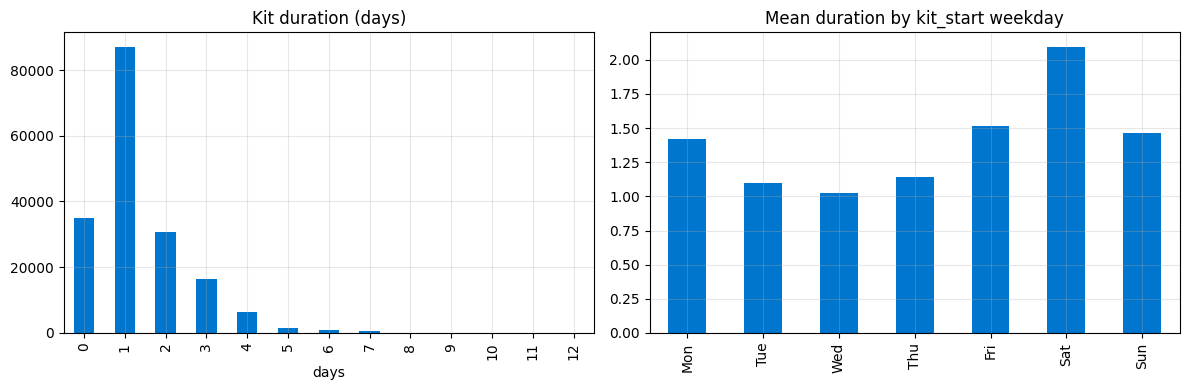

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
tr[tr.dur.between(0,12)].dur.value_counts().sort_index().plot.bar(ax=ax[0],color='#0076CE'); ax[0].set_title('Kit duration (days)'); ax[0].set_xlabel('days')
T0=tr[tr.dur>=0]; w=T0.assign(dow=T0.kit_start.dt.dayofweek).groupby('dow').dur.agg(['mean','median'])
w.index=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']; w['mean'].plot.bar(ax=ax[1],color='#0076CE'); ax[1].set_title('Mean duration by kit_start weekday')
plt.tight_layout(); plt.savefig(OUT+'fig1_target_and_weekday.png',dpi=110); plt.show()

In [ ]:
m=T0.groupby(T0.kit_start.dt.to_period('M')).agg(mean_dur=('dur','mean'),orders=('dur','size'))
print(m.round(2))
print('\nMean duration by warehouse (mcid):'); print(T0.groupby('mcid').dur.agg(['mean','count']).round(2))
print('\nSpearman corr with duration:');
t=T0.assign(ship_gap=(T0.est_ship_date-T0.kit_start).dt.days)
print(t[['dur','ship_gap','order_amt','quantity_produced']].corr(method='spearman').dur.round(3).to_dict())

           mean_dur  orders
kit_start                  
2025-03        1.98   16692
2025-04        1.16   16756
2025-05        1.42   16572
2025-06        1.11   13004
2025-07        0.99   17996
2025-08        1.24   15956
2025-09        1.23   14869
2025-10        1.24   19212
2025-11        1.64   14685
2025-12        1.72   17679
2026-01        1.51   15698

Mean duration by warehouse (mcid):
      mean   count
mcid              
3JHF  1.77    1465
3JL3  1.35    4754
3JU   1.59   46724
KHO   1.29  115641
KL1   1.46    5854
KL3   2.01    1607
KLJ   2.15      13
RCH   1.25    3061

Spearman corr with duration:
{'dur': 1.0, 'ship_gap': 0.089, 'order_amt': 0.087, 'quantity_produced': -0.037}


**Read-out:** duration is mostly a *factory-state* story: weekday of start (Fri/Sat starts spill over the weekend), month, and warehouse. Order attributes (amount, quantity) are weak. This shapes the feature plan below.

## 4. Prediction & Eng.

In [ ]:
df = add_forward_features(build_features(tr,inf,cal,cap,em), cap)
T = df[(df.is_train==1)&(df.dur>=0)].copy()          # A2
cut = pd.Timestamp('2025-12-15')
a, b = T[T.kit_start<cut], T[T.kit_start>=cut]; y = b.dur.values
print('train',len(a),'validation',len(b))
F_ALL = [f for f in FEATS if f!='family_desc_cat'] + EXTRA     # family_desc dropped: high-cardinality, overfit in tests
F_NOFACTORY = [f for f in F_ALL if f in ['order_amt','log_amt','amt_per_unit','quantity_produced','line_qty','tie_num','cfs_flag','is_cfi','dl_lag','ship_gap','mcid_is_site','n_ties_in_order','n_rows_in_order','qty_share','expected_build_minutes','expected_burn_minutes','expected_kit_minutes','kit_min_total','burn_min_total','dow','fiscal_qtr','fiscal_month','is_weekend','is_holiday','is_eoq','is_idc'] or f.endswith('_cat')]
rows=[]
def score(name,p):
    p=np.asarray(p); rows.append(dict(model=name,MAE_days=np.abs(p-y).mean(),exact_hit=np.mean(p==y),within_1_day=np.mean(np.abs(p-y)<=1)))
score('B1 always 1 day', np.ones(len(b)))
med=a.groupby(['mcid','dow']).dur.median(); score('B2 median by warehouse x weekday',[med.get((m,d),1) for m,d in zip(b.mcid,b.dow)])
PARAMS=dict(objective='multiclass',n_estimators=250,learning_rate=0.05,num_leaves=15,min_child_samples=100,subsample=0.7,subsample_freq=1,colsample_bytree=0.6,reg_lambda=5,max_bin=63,verbose=-1,n_jobs=1)
K=7   # classes 0..6, 7 = 7+ days
def median_from_proba(pr): return (pr.cumsum(1)>=0.5).argmax(1)
m0=lgb.LGBMClassifier(**PARAMS).fit(a[F_NOFACTORY],a.dur.clip(upper=K)); score('M0 LGBM, order + basic calendar only',median_from_proba(m0.predict_proba(b[F_NOFACTORY])))
m1=lgb.LGBMClassifier(**PARAMS).fit(a[F_ALL],a.dur.clip(upper=K)); pr1=m1.predict_proba(b[F_ALL]); p1=median_from_proba(pr1); score('M1 LGBM, + workload & capacity (final)',p1)
res=pd.DataFrame(rows).round(3); print(res.to_string(index=False)); res.to_csv(OUT+'validation_metrics.csv',index=False)

train 154742 validation 24377


                                 model  MAE_days  exact_hit  within_1_day
                       B1 always 1 day     0.926      0.474         0.800
      B2 median by warehouse x weekday     0.837      0.505         0.839
  M0 LGBM, order + basic calendar only     0.897      0.469         0.819
M1 LGBM, + workload & capacity (final)     0.793      0.505         0.858


**Note** : the model beats both baselines, and almost all of the gain comes from the workload/capacity features, not the order attributes.

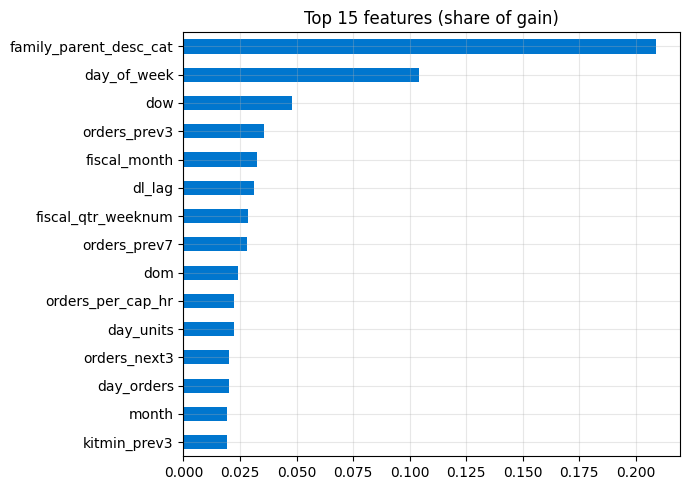

                       orders    MAE  exact
kit_start                                  
2025-12-15/2025-12-21  4415.0  0.807  0.460
2025-12-22/2025-12-28  2995.0  1.092  0.423
2025-12-29/2026-01-04  2285.0  0.939  0.424
2026-01-05/2026-01-11  4022.0  0.726  0.568
2026-01-12/2026-01-18  3462.0  0.772  0.551
2026-01-19/2026-01-25  3248.0  0.552  0.572
2026-01-26/2026-02-01  3950.0  0.752  0.502

Actual (rows) vs predicted (cols), row-normalised:
p       0     1     2     3     4
dur                              
0.0  0.01  0.93  0.06  0.00  0.00
1.0  0.00  0.88  0.11  0.02  0.00
2.0  0.05  0.53  0.38  0.03  0.01
3.0  0.01  0.37  0.41  0.19  0.02
4.0  0.00  0.37  0.32  0.30  0.00
5.0  0.00  0.67  0.22  0.10  0.00


In [ ]:
imp=pd.Series(m1.booster_.feature_importance('gain'),F_ALL).sort_values(ascending=False); imp=(imp/imp.sum())
imp.head(15)[::-1].plot.barh(color='#0076CE',figsize=(7,5)); plt.title('Top 15 features (share of gain)'); plt.tight_layout(); plt.savefig(OUT+'fig2_importance.png',dpi=110); plt.show()
bb=b.assign(p=p1); wk=bb.groupby(bb.kit_start.dt.to_period('W')).apply(lambda g: pd.Series({'orders':len(g),'MAE':np.abs(g.p-g.dur).mean(),'exact':(g.p==g.dur).mean()})).round(3)
print(wk);
ct=pd.crosstab(bb.dur.clip(upper=5),bb.p.clip(upper=5),normalize='index').round(2); print('\nActual (rows) vs predicted (cols), row-normalised:'); print(ct)

**Read-out:** weeks around Christmas / New Year are hardest (low volume, holiday shutdown, MAE > 1). The model rarely predicts 0 or 3+ days: it is good at the typical case and blind to the tails, because tails are driven by things not in the data.

## 5. Final fit on all training data, predict inferences

In [ ]:
Xtr=T[F_ALL]; ytr=T.dur.clip(upper=K)
mf=lgb.LGBMClassifier(**PARAMS).fit(Xtr,ytr)
I=df[df.is_train==0].reset_index(drop=True)
assert len(I)==len(inf) and (I.sales_order_id.values==inf.sales_order_id.values).all()   # same order as the input file
pf=median_from_proba(mf.predict_proba(I[F_ALL]))
pred_kit_end=(inf.kit_start.values.astype('datetime64[D]')+pf.astype('timedelta64[D]')).astype('datetime64[ns]')
print(pd.Series(pf).value_counts(normalize=True).sort_index().round(3).to_dict())
print('shape',pred_kit_end.shape,pred_kit_end.dtype,pred_kit_end[:3])
np.save(OUT+'YourName_DS_Case_Predictions_2026.npy',pred_kit_end)
inf.assign(pred_kit_end=pred_kit_end,pred_days=pf)[['sales_order_id','family_desc','kit_start','pred_days','pred_kit_end']].to_csv(OUT+'YourName_DS_Case_Predictions_2026.csv',index=False)
print('saved')

{1: 0.358, 2: 0.395, 3: 0.207, 4: 0.037, 5: 0.001, 7: 0.003}
shape (12069,) datetime64[ns] ['2026-02-15T00:00:00.000000000' '2026-02-12T00:00:00.000000000'
 '2026-02-27T00:00:00.000000000']
saved


## 6. Limitations and next steps
- **Tails:** 3+ day orders are hard to flag from this data. Adding *backlog* (open WIP by day) and *parts availability* would help most. Capacity for future dates is assumed to be the plan. If it is only recorded after the fact, forward features overstate accuracy.
- **Time span:** less than 1 year of data, so fiscal seasonality (quarter-end) is estimated from a singular cycle.

- **Additionally:** The records cover one site (KHO), and this analysis does not show that performance transfers to other sites. More than one-fifth of inference rows lack expected kit minutes. The median-based model has limited differentiation and cannot account for changing congestion or staffing from the supplied data. The exact-day hit rate is below 50%; the typical absolute error is one day. Classification results depend on arbitrary duration buckets and must not be interpreted as SLA threshold performance.